# **03 Diagnóstico estatístico visual**

---

#### Este arquivo é responsável pelo diágnóstico estatístico visual, buscando entender e responder perguntas de forma mais clara e obetiva por meio de gráficos

## Perguntas e valores análisadas


- **Análise de Idade**: Os funcionários demitidos possuem perfil etário diferente dos funcionários ativos ?

- **Análise Salarial**: Existe relação entre a remuneração mensal e o desligamento dos funcionários ?

- **Análise de Distância de Casa**: A distância entre a residência e o trabalho influencia no atrito e na retenção ?

- **Análise de Tempo de Empresa**: Os funcionários recém-contratados saem mais da empresa ou apresentam maior risco de desligamento ?

- **Análise de Horas Extras**: A realização de horas extras e a carga de trabalho estão associadas ao aumento do atrito ?

- **Análise de Satisfação dos Funcionários**: Funcionários menos satisfeitos com o ambiente, trabalho, gestor e equilíbrio de vida tendem a sair mais ?

- **Análise de Departamento**: Quais departamentos e áreas da empresa apresentam maior atrito e são mais afetados pelas demissões ?

- **Análise de Cargo**: Quais cargos e posições hierárquicas apresentam maior rotatividade e volume de desligamentos ?

- **Análise de Escolaridade**: O nível educacional dos colaboradores possui relação direta com a taxa de demissão ?

- **Análise de Gênero**: Existe diferença significativa e desequilíbrio na retenção de talentos entre os gêneros ?

- **Matriz de Correlação**: Quais são as relações, correlações fortes e redundâncias entre as variáveis numéricas mapeadas ?

- **Ranking Final de Fatores de Atrito**: Quais fatores consolidados parecem ter maior influência e relevância para prever o desligamento ?


---

# Código:

In [29]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/tabela_base_traduzida.csv')

sns.set_theme( style = "darkgrid", palette = "cividis", context = "notebook")

### **Análise de Idade**
Os funcionários demitidos possuem perfil etário diferente dos funcionários ativos ?

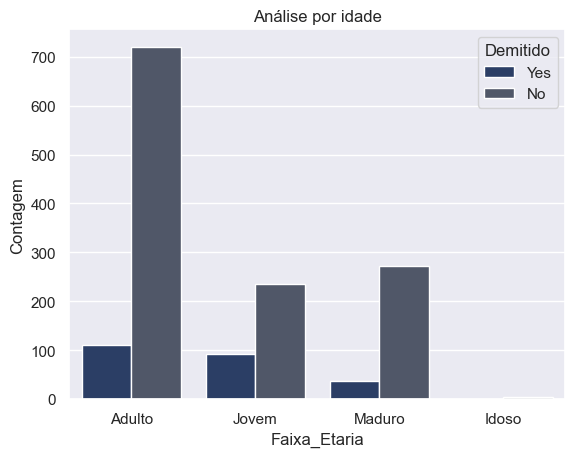

In [10]:
ordem = (df["Faixa_Etaria"].value_counts(ascending=False).index)

g = sns.countplot(data = df, x = "Faixa_Etaria", hue = "Demitido", order = ordem)
g.set_title("Análise por idade")
g.set_ylabel("Contagem")
g.label_outer("Teste")

#gi.text(x=1 (posição horizontal), y=50 (Posição vertical), s = "Texto") 

### **Análise Salarial**
    Existe relação entre a remuneração mensal e o desligamento dos funcionários ?

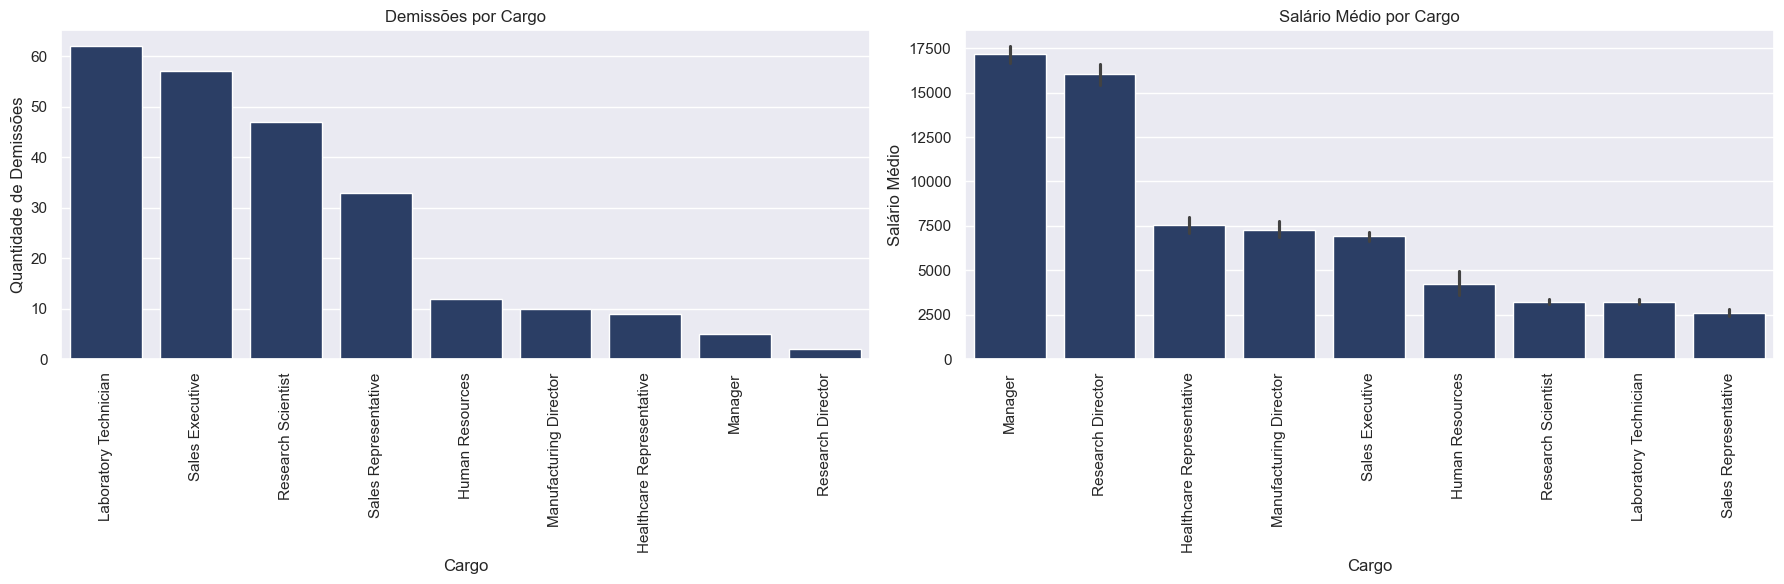

In [52]:
ordem_demissao_cargo = (df[df["Demitido"] == "Yes"]["Cargo"].value_counts(ascending=False).index)

ordem_salario_cargo = (df.groupby("Cargo")["Renda_Mensal"].mean().sort_values(ascending=False).index)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(data = df[df["Demitido"] == "Yes"], x = "Cargo", order = ordem_demissao_cargo, ax = ax[0])
ax[0].set_title("Demissões por Cargo")
ax[0].set_xlabel("Cargo")
ax[0].set_ylabel("Quantidade de Demissões")

sns.barplot(data=df, x = "Cargo", y = "Renda_Mensal", estimator = "mean", order = ordem_salario_cargo, ax = ax[1])
ax[1].set_title("Salário Médio por Cargo")
ax[1].set_xlabel("Cargo")
ax[1].set_ylabel("Salário Médio")

for eixo in ax: eixo.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

### **Análise de Distância de Casa:** 
    A distância entre a residência e o trabalho influencia no atrito e nas demissões ?

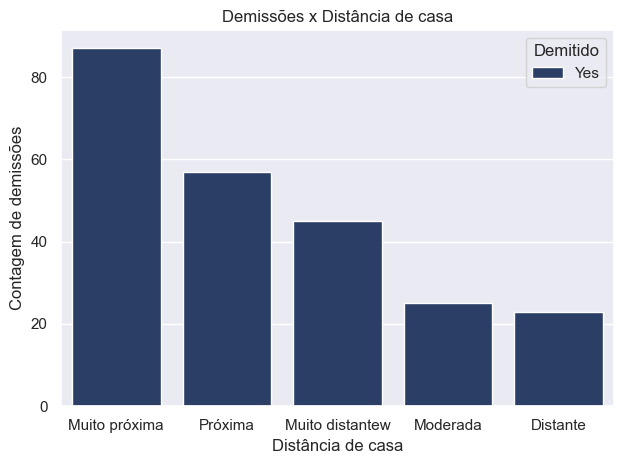

In [62]:
ordem_distancia = ( df[df["Demitido"] == "Yes"] ["Faixa_Distancia_de_Casa"].value_counts().index)

g = sns.countplot( data = df[df["Demitido"] == "Yes"], x = "Faixa_Distancia_de_Casa", hue = "Demitido", order = ordem_distancia)
g.set_xlabel("Distância de casa")
g.set_ylabel("Contagem de demissões")
g.set_title("Demissões x Distância de casa")

plt.tight_layout()
plt.show()